# Выпускной проект - Промышленность

## Описание проекта:
Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Наша задача — построить модель, которая будет предсказывать температуру сплава. Выполняя задание, мы решим задачу регрессии.

## Цель проекта:
Разработка модели машинного обучения, для предсказания температуры сплава.

## План проекта:  
1. Загрузка данных
2. Исследовательский анализ и предобработка данных
3. Обучение модели
4. Тестирование модели и демонстрация ее работы
5. Общий вывод

## Описание данных:

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:
- steel.data_arc — данные об электродах;
- steel.data_bulk — данные об объёме сыпучих материалов;
- steel.data_bulk_time — данные о времени подачи сыпучих материалов;
- steel.data_gas — данные о продувке сплава газом;
- steel.data_temp — данные об измерениях температуры;
- steel.data_wire — данные об объёме проволочных материалов;
- steel.data_wire_time — данные о времени подачи проволочных материалов.  

Таблица **steel.data_arc**
- key — номер партии;
- BeginHeat — время начала нагрева;
- EndHeat — время окончания нагрева;
- ActivePower — значение активной мощности;
- ReactivePower — значение реактивной мощности.  

Таблица **steel.data_bulk**  
- key — номер партии;
- Bulk1 … Bulk15 — объём подаваемого материала.  

Таблица **steel.data_bulk_time**
- key — номер партии;
- Bulk1 … Bulk15 — время подачи материала.  

Таблица **steel.data_gas**  
- key — номер партии;
- gas — объём подаваемого газа.  

Таблица **steel.data_temp**
- key — номер партии;
- MesaureTime — время замера;
- Temperature — значение температуры.  

Таблица **steel.data_wire**
- key — номер партии;
- Wire1 … Wire9 — объём подаваемых проволочных материалов.  

Таблица **steel.data_wire_time**  
- key — номер партии;
- Wire1 … Wire9 — время подачи проволочных материалов.  

Во всех файлах столбец key содержит номер партии. В таблицах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

### 1. Загрузка данных

In [1]:
# загрузка библиотек

import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import cross_val_score
from scikeras.wrappers import KerasRegressor

In [2]:
# назначение константы

RANDOM_STATE = 10626

In [3]:
# загрузка бд

path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

tables_query = "SELECT name FROM sqlite_master WHERE type='table'"
tables = pd.read_sql(tables_query, engine)

print("Таблицы в базе данных:")
display(tables)

Таблицы в базе данных:


,name
0,data_arc
1,data_bulk
2,data_bulk_time
3,data_wire_time
4,contract
5,personal
6,phone
7,internet
8,data_gas
9,data_temp


In [4]:
# размер таблиц

target_tables = ['data_arc', 'data_bulk', 'data_bulk_time', 'data_gas', 
                 'data_temp', 'data_wire', 'data_wire_time']

for table in target_tables:
    df = pd.read_sql(f"SELECT * FROM {table}", engine)
    print(f"{table}: {len(df)} строк, {len(df.columns)} столбцов")

data_arc: 14876 строк, 5 столбцов
data_bulk: 3129 строк, 16 столбцов
data_bulk_time: 3129 строк, 16 столбцов
data_gas: 3239 строк, 2 столбцов
data_temp: 18092 строк, 3 столбцов
data_wire: 3081 строк, 10 столбцов
data_wire_time: 3081 строк, 10 столбцов


Загрузили таблицы из бд. Есть 11 таблиц, из ТЗ нужны 7. Данные в таблицах есть.

### 2. Исследовательский анализ и предобработка данных

In [5]:
# steel.data_arc

df_arc = pd.read_sql("SELECT * FROM data_arc", engine)

print("=== Общая информация ===")
df_arc.info()

print("\n=== Пропуски ===")
print(df_arc.isnull().sum())

print("\n=== Описательная статистика ===")
display(df_arc.describe())

print(f"\nУникальных партий (key): {df_arc['key'].nunique()}")

print("\n=== Первые 5 строк ===")
display(df_arc.head())

=== Общая информация ===
<class 'pandas.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  str    
 2   Конец нагрева дугой   14876 non-null  str    
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 581.2 KB

=== Пропуски ===
key                     0
Начало нагрева дугой    0
Конец нагрева дугой     0
Активная мощность       0
Реактивная мощность     0
dtype: int64

=== Описательная статистика ===


,key,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284



Уникальных партий (key): 3214

=== Первые 5 строк ===


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


In [6]:
# поиск аномальных значений

anomaly = df_arc[df_arc['Реактивная мощность'] < 0]
print("=== Аномальные строки ===")
display(anomaly)

if len(anomaly) > 0:
    bad_key = anomaly['key'].values[0]
    print(f"\nПроблемная партия: {bad_key}")
    print(f"Строк с этой партией до удаления: {len(df_arc[df_arc['key'] == bad_key])}")
    
    df_arc = df_arc[df_arc['key'] != bad_key]
    print(f"Строк после удаления: {len(df_arc)}")
    print(f"Уникальных партий после удаления: {df_arc['key'].nunique()}")

=== Аномальные строки ===


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924



Проблемная партия: 2116
Строк с этой партией до удаления: 4
Строк после удаления: 14872
Уникальных партий после удаления: 3213


In [7]:
# генерация новых признаков

df_arc['Начало нагрева дугой'] = pd.to_datetime(df_arc['Начало нагрева дугой'])
df_arc['Конец нагрева дугой'] = pd.to_datetime(df_arc['Конец нагрева дугой'])

df_arc['Длительность нагрева (сек)'] = (df_arc['Конец нагрева дугой'] - df_arc['Начало нагрева дугой']).dt.total_seconds()
df_arc['Полная мощность'] = df_arc['Активная мощность'] + df_arc['Реактивная мощность']
df_arc['Соотношение активной к реактивной'] = df_arc['Активная мощность'] / (df_arc['Реактивная мощность'] + 1e-9)

print("=== Новые признаки (первые 5 строк) ===")
display(df_arc[['key', 'Длительность нагрева (сек)', 'Полная мощность', 'Соотношение активной к реактивной']].head())

print(f"\nБесконечностей в соотношении: {np.isinf(df_arc['Соотношение активной к реактивной']).sum()}")

=== Новые признаки (первые 5 строк) ===


,key,Длительность нагрева (сек),Полная мощность,Соотношение активной к реактивной
0,1,228.0,0.516383,1.444382
1,1,185.0,1.243096,1.603680
2,1,172.0,1.010773,1.348123
3,1,365.0,0.898475,1.364539
4,1,148.0,1.510824,1.347126



Бесконечностей в соотношении: 0


In [8]:
# агрегация данных

df_arc_agg = df_arc.groupby('key').agg(
    Количество_нагревов=('Начало нагрева дугой', 'count'),
    Суммарная_длительность_нагрева=('Длительность нагрева (сек)', 'sum'),
    Средняя_длительность_нагрева=('Длительность нагрева (сек)', 'mean'),
    Макс_длительность_нагрева=('Длительность нагрева (сек)', 'max'),
    Средняя_активная_мощность=('Активная мощность', 'mean'),
    Средняя_реактивная_мощность=('Реактивная мощность', 'mean'),
    Средняя_полная_мощность=('Полная мощность', 'mean'),
    Суммарная_активная_мощность=('Активная мощность', 'sum'),
    Соотношение_мощностей_среднее=('Соотношение активной к реактивной', 'mean')
).reset_index()

print(f"Размер агрегированной таблицы: {df_arc_agg.shape}")
print(f"Уникальных партий: {df_arc_agg['key'].nunique()}")
display(df_arc_agg.head())

Размер агрегированной таблицы: (3213, 10)
Уникальных партий: 3213


,key,Количество_нагревов,Суммарная_длительность_нагрева,Средняя_длительность_нагрева,Макс_длительность_нагрева,Средняя_активная_мощность,Средняя_реактивная_мощность,Средняя_полная_мощность,Суммарная_активная_мощность,Соотношение_мощностей_среднее
0,1,5,1098.0,219.60,365.0,0.607346,0.428564,1.035910,3.036730,1.421570
1,2,4,811.0,202.75,338.0,0.534852,0.363339,0.898191,2.139408,1.479201
2,3,5,655.0,131.00,280.0,0.812728,0.587491,1.400220,4.063641,1.396069
3,4,4,741.0,185.25,278.0,0.676622,0.514248,1.190870,2.706489,1.307446
4,5,4,869.0,217.25,415.0,0.563238,0.421998,0.985235,2.252950,1.328894


**Загружено:** 14 876 строк, 5 столбцов.  
**Пропуски:** отсутствуют.  
**Аномалия:** в столбце «Реактивная мощность» обнаружено значение -715.48 в партии №2116. Партия удалена полностью (4 строки).  
**Сгенерированы признаки:**  Длительность нагрева (сек),полная мощность (активная + реактивная), соотношение активной мощности к реактивной.
**Агрегация по key (3 213 партий):** Количество нагревов, суммарная / средняя / максимальная длительность нагрева, средняя активная, реактивная, полная мощность, суммарная активная мощность, среднее соотношение мощностей.

In [9]:
# steel.data_bulk

df_bulk = pd.read_sql("SELECT * FROM data_bulk", engine)

print("=== data_bulk ===")
print(f"Строк: {len(df_bulk)}, столбцов: {len(df_bulk.columns)}")
print(f"Уникальных партий: {df_bulk['key'].nunique()}")
print(f"\nПропуски:\n{df_bulk.isnull().sum().to_string()}")
print(f"\nОписательная статистика:")
display(df_bulk.describe())

=== data_bulk ===
Строк: 3129, столбцов: 16
Уникальных партий: 3129

Пропуски:
key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881

Описательная статистика:


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477
std,933.337642,18.277654,21.180578,75.483494,48.184126
min,1.000000,10.000000,228.000000,6.000000,12.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000


In [10]:
# обработка пропусков и создание признаков

bulk_cols = [f'Bulk {i}' for i in range(1, 16)]

for col in bulk_cols:
    df_bulk[col] = pd.to_numeric(df_bulk[col], errors='coerce').fillna(0)

df_bulk['Всего_сыпучих_материалов'] = df_bulk[bulk_cols].sum(axis=1)
df_bulk['Количество_видов_сыпучих'] = (df_bulk[bulk_cols] > 0).sum(axis=1)
df_bulk['Средний_объём_сыпучих'] = df_bulk[bulk_cols].mean(axis=1)

print(f"Пропусков после обработки: {df_bulk[bulk_cols].isnull().sum().sum()}")
print(f"Уникальных партий: {df_bulk['key'].nunique()}")
display(df_bulk[['key', 'Всего_сыпучих_материалов', 'Количество_видов_сыпучих', 'Средний_объём_сыпучих']].head())

Пропусков после обработки: 0
Уникальных партий: 3129


,key,Всего_сыпучих_материалов,Количество_видов_сыпучих,Средний_объём_сыпучих
0,1,553.0,4,36.866667
1,2,582.0,4,38.800000
2,3,544.0,4,36.266667
3,4,595.0,4,39.666667
4,5,584.0,4,38.933333


**Загружено:** 3 129 строк, 16 столбцов (key + Bulk 1...Bulk 15).  
**Пропуски:** до 3 107 из 3 129. По заданию пропуск = материал не добавляли. Заменены на 0.  
**Аномалии:** не обнаружены — значения в разумных диапазонах (6–454 кг).  
**Созданы признаки:** Всего сыпучих материалов (сумма по 15 столбцам), количество видов сыпучих (сколько разных материалов добавили), средний объём сыпучих.


In [11]:
# steel.data_bulk_time

df_bulk_time = pd.read_sql("SELECT * FROM data_bulk_time", engine)

time_cols = [f'Bulk {i}' for i in range(1, 16)]

for col in time_cols:
    df_bulk_time[col] = pd.to_datetime(df_bulk_time[col], errors='coerce')

print("=== 1. Общая информация ===")
print(f"Строк: {len(df_bulk_time)}, столбцов: {len(df_bulk_time.columns)}")
print(f"Уникальных партий: {df_bulk_time['key'].nunique()}")

print("\n=== 2. Пропуски ===")
missing = df_bulk_time[time_cols].isnull().sum()
missing_pct = (missing / len(df_bulk_time) * 100).round(1)
print(f"{'Столбец':<12} {'Пропусков':<12} {'%'}")
for col in time_cols:
    print(f"{col:<12} {missing[col]:<12} {missing_pct[col]}%")

print(f"\nВсего непустых значений: {df_bulk_time[time_cols].notna().sum().sum()} из {len(df_bulk_time)*15}")

valid_times = df_bulk_time[time_cols].stack().dropna()
print(f"\n=== 3. Проверка адекватности времени ===")
print(f"Мин: {valid_times.min()}")
print(f"Макс: {valid_times.max()}")
print(f"Размах: {valid_times.max() - valid_times.min()}")

print(f"\n=== 4. Пример времен внутри партии (key=1) ===")
example = df_bulk_time[df_bulk_time['key'] == 1][time_cols]
display(example)

=== 1. Общая информация ===
Строк: 3129, столбцов: 16
Уникальных партий: 3129

=== 2. Пропуски ===
Столбец      Пропусков    %
Bulk 1       2877         91.9%
Bulk 2       3107         99.3%
Bulk 3       1831         58.5%
Bulk 4       2115         67.6%
Bulk 5       3052         97.5%
Bulk 6       2553         81.6%
Bulk 7       3104         99.2%
Bulk 8       3128         100.0%
Bulk 9       3110         99.4%
Bulk 10      2953         94.4%
Bulk 11      2952         94.3%
Bulk 12      679          21.7%
Bulk 13      3111         99.4%
Bulk 14      323          10.3%
Bulk 15      881          28.2%

Всего непустых значений: 11159 из 46935

=== 3. Проверка адекватности времени ===
Мин: 2019-05-03 11:10:43
Макс: 2019-09-06 17:26:33
Размах: 126 days 06:15:50

=== 4. Пример времен внутри партии (key=1) ===


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43


In [12]:
# пропуски, агрегация

time_cols_filtered = [col for col in time_cols if col != 'Bulk 8']

for col in time_cols_filtered:
    df_bulk_time[col] = df_bulk_time[col].apply(lambda x: x.timestamp() if pd.notna(x) else np.nan)

df_bulk_time[time_cols_filtered] = df_bulk_time[time_cols_filtered].fillna(0)

df_bulk_time['Количество_подач_сыпучих'] = (df_bulk_time[time_cols_filtered] > 0).sum(axis=1)
df_bulk_time['Мин_время_сыпучих'] = df_bulk_time[time_cols_filtered].replace(0, np.nan).min(axis=1)
df_bulk_time['Макс_время_сыпучих'] = df_bulk_time[time_cols_filtered].max(axis=1)
df_bulk_time['Размах_времени_сыпучих'] = df_bulk_time['Макс_время_сыпучих'] - df_bulk_time['Мин_время_сыпучих'].fillna(0)

print(f"Уникальных партий: {df_bulk_time['key'].nunique()}")
print(f"\nРазмах времени (сек): мин={df_bulk_time['Размах_времени_сыпучих'].min():.0f}, макс={df_bulk_time['Размах_времени_сыпучих'].max():.0f}")
display(df_bulk_time[['key', 'Количество_подач_сыпучих', 'Размах_времени_сыпучих']].head())

Уникальных партий: 3129

Размах времени (сек): мин=0, макс=13683


,key,Количество_подач_сыпучих,Размах_времени_сыпучих
0,1,4,1085.0
1,2,4,1000.0
2,3,4,983.0
3,4,4,878.0
4,5,4,205.0


**Загружено:** 3 129 строк, 16 столбцов.  
**Bulk 8 удалён** (100% пустой).  
**Пропуски** заменены на 0 (материал не подавали в этой итерации).  
**Адекватность:** макс размах ~3.8 часа — допустимо.  
**Созданы признаки:** количество подач сыпучих, размах времени подачи.

In [13]:
# steel.data_gas

df_gas = pd.read_sql("SELECT * FROM data_gas", engine)

print("=== data_gas ===")
print(f"Строк: {len(df_gas)}, столбцов: {len(df_gas.columns)}")
print(f"Уникальных партий: {df_gas['key'].nunique()}")
print(f"\nПропуски:\n{df_gas.isnull().sum().to_string()}")
print(f"\nОписательная статистика:")
display(df_gas.describe())

=== data_gas ===
Строк: 3239, столбцов: 2
Уникальных партий: 3239

Пропуски:
key      0
Газ 1    0

Описательная статистика:


,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


**Загружено:** 3 239 строк, 2 столбца.  
**Пропуски:** отсутствуют.  
**Аномалии:** не обнаружены, значения в диапазоне 0.008–78 м³ — адекватно.  
**Действие:** оставляем как есть, агрегировать нечего — каждая партия уже в одной строке.

In [14]:
# steel.data_temp

df_temp = pd.read_sql("SELECT * FROM data_temp", engine)

df_temp['Температура'] = pd.to_numeric(df_temp['Температура'], errors='coerce')

df_temp['Время замера'] = pd.to_datetime(df_temp['Время замера'])

print("=== data_temp ===")
print(f"Строк: {len(df_temp)}, столбцов: {len(df_temp.columns)}")
print(f"Уникальных партий: {df_temp['key'].nunique()}")
print(f"\nПропуски:\n{df_temp.isnull().sum().to_string()}")
print(f"\nОписательная статистика:")
display(df_temp.describe())

anomaly_temp = df_temp[df_temp['Температура'] < 1500]
print(f"\nЗамеров с температурой < 1500: {len(anomaly_temp)} из {len(df_temp)}")
if len(anomaly_temp) > 0:
    print("Примеры аномальных замеров:")
    display(anomaly_temp.head(10))

=== data_temp ===
Строк: 18092, столбцов: 3
Уникальных партий: 3216

Пропуски:
key                0
Время замера       0
Температура     3427

Описательная статистика:


,key,Время замера,Температура
count,18092.000000,18092,14665.000000
mean,1616.460977,2019-07-05 13:36:58.791620,1590.722741
min,1.000000,2019-05-03 11:02:04,1191.000000
25%,807.750000,2019-06-04 00:35:01.250000,1580.000000
50%,1618.000000,2019-07-03 02:11:48,1590.000000
75%,2429.000000,2019-08-07 23:10:05.250000,1599.000000
max,3241.000000,2019-09-06 17:30:05,1705.000000
std,934.641385,NaN,20.394381



Замеров с температурой < 1500: 5 из 18092
Примеры аномальных замеров:


,key,Время замера,Температура
4883,867,2019-06-06 08:03:39,1191.0
6784,1214,2019-06-18 08:01:03,1208.0
9050,1619,2019-07-03 02:34:41,1218.0
11495,2052,2019-07-25 08:49:15,1227.0
14283,2561,2019-08-12 18:49:29,1204.0


In [15]:
# аномалии, пропуски

df_temp = df_temp[df_temp['Температура'] >= 1500]

df_temp['Температура'] = df_temp.groupby('key')['Температура'].transform(
    lambda x: x.fillna(x.median())
)

print(f"Пропусков в температуре после заполнения: {df_temp['Температура'].isnull().sum()}")

valid_keys = df_temp.groupby('key').filter(lambda x: len(x) >= 2)['key'].unique()
df_temp = df_temp[df_temp['key'].isin(valid_keys)]

print(f"Партий после фильтрации: {df_temp['key'].nunique()}")

df_temp_agg = df_temp.groupby('key').agg(
    Начальная_температура=('Температура', 'first'),
    Конечная_температура=('Температура', 'last'),
    Количество_замеров=('Температура', 'count')
).reset_index()

print(f"Партий в агрегированной таблице: {len(df_temp_agg)}")
display(df_temp_agg.head())

Пропусков в температуре после заполнения: 0
Партий после фильтрации: 2475
Партий в агрегированной таблице: 2475


,key,Начальная_температура,Конечная_температура,Количество_замеров
0,1,1571.0,1613.0,6
1,2,1581.0,1602.0,5
2,3,1596.0,1599.0,6
3,4,1601.0,1625.0,5
4,5,1576.0,1602.0,5


**`data_temp` (температура):**
- Загружено: 18 092 строки, 3 столбца.
- Аномалии: 5 замеров < 1500° — удалены.
- Пропуски: 3 427 в температуре — заполнены медианой внутри партии.
- Фильтрация: оставлены партии с ≥ 2 замерами → 2 475 партий.
- Целевой признак: конечная температура (`Конечная_температура`).
- Входные признаки: начальная температура, количество замеров.
- Средняя температура и размах исключены — содержат промежуточные замеры (потенциальная утечка целевого признака).

In [16]:
# stee.data_wire

df_wire = pd.read_sql("SELECT * FROM data_wire", engine)

print("=== data_wire ===")
print(f"Строк: {len(df_wire)}, столбцов: {len(df_wire.columns)}")
print(f"Уникальных партий: {df_wire['key'].nunique()}")
print(f"\nПропуски:\n{df_wire.isnull().sum().to_string()}")
print(f"\nОписательная статистика:")
display(df_wire.describe())

=== data_wire ===
Строк: 3081, столбцов: 10
Уникальных партий: 3081

Пропуски:
key          0
Wire 1      26
Wire 2    2002
Wire 3    3018
Wire 4    3067
Wire 5    3080
Wire 6    3008
Wire 7    3070
Wire 8    3062
Wire 9    3052

Описательная статистика:


,key,Wire 1
count,3081.000000,3055.000000
mean,1623.426485,100.895853
std,932.996726,42.012518
min,1.000000,1.918800
25%,823.000000,72.115684
50%,1619.000000,100.158234
75%,2434.000000,126.060483
max,3241.000000,330.314424


In [17]:
# пропуски, агрегация

wire_cols = [f'Wire {i}' for i in range(1, 10)]

for col in wire_cols:
    df_wire[col] = pd.to_numeric(df_wire[col], errors='coerce')

df_wire[wire_cols] = df_wire[wire_cols].fillna(0)

df_wire['Всего_проволоки'] = df_wire[wire_cols].sum(axis=1)
df_wire['Количество_видов_проволоки'] = (df_wire[wire_cols] > 0).sum(axis=1)
df_wire['Средний_объём_проволоки'] = df_wire[wire_cols].mean(axis=1)

print(f"Пропусков: {df_wire[wire_cols].isnull().sum().sum()}")
print(f"Уникальных партий: {df_wire['key'].nunique()}")
display(df_wire[['key', 'Всего_проволоки', 'Количество_видов_проволоки', 'Средний_объём_проволоки']].head())

Пропусков: 0
Уникальных партий: 3081


,key,Всего_проволоки,Количество_видов_проволоки,Средний_объём_проволоки
0,1,60.059998,1,6.673333
1,2,96.052315,1,10.672479
2,3,91.160157,1,10.128906
3,4,89.063515,1,9.895946
4,5,98.352796,2,10.928088


**Загружено:** 3 081 строка, 10 столбцов.  
**Пропуски:** до 3 080. Заменены на 0 (материал не добавляли).  
**Аномалии:** не обнаружены.  
**Созданы признаки:** всего проволоки, количество видов, средний объём.

In [18]:
# steel.data_wire_time

df_wire_time = pd.read_sql("SELECT * FROM data_wire_time", engine)

wire_time_cols = [f'Wire {i}' for i in range(1, 10)]

for col in wire_time_cols:
    df_wire_time[col] = pd.to_datetime(df_wire_time[col], errors='coerce')
    df_wire_time[col] = df_wire_time[col].apply(lambda x: x.timestamp() if pd.notna(x) else np.nan)

df_wire_time['Количество_подач_проволоки'] = df_wire_time[wire_time_cols].notna().sum(axis=1)
df_wire_time['Мин_время_проволоки'] = df_wire_time[wire_time_cols].min(axis=1)
df_wire_time['Макс_время_проволоки'] = df_wire_time[wire_time_cols].max(axis=1)
df_wire_time['Размах_времени_проволоки'] = df_wire_time['Макс_время_проволоки'] - df_wire_time['Мин_время_проволоки']

df_wire_time[wire_time_cols] = df_wire_time[wire_time_cols].fillna(0)
df_wire_time[['Мин_время_проволоки', 'Макс_время_проволоки', 'Размах_времени_проволоки']] = \
    df_wire_time[['Мин_время_проволоки', 'Макс_время_проволоки', 'Размах_времени_проволоки']].fillna(0)

print(f"Уникальных партий: {df_wire_time['key'].nunique()}")
print(f"Размах времени (сек): мин={df_wire_time['Размах_времени_проволоки'].min():.0f}, макс={df_wire_time['Размах_времени_проволоки'].max():.0f}")
print(f"Партий с >1 подачей: {(df_wire_time['Количество_подач_проволоки'] > 1).sum()}")
display(df_wire_time[['key', 'Количество_подач_проволоки', 'Размах_времени_проволоки']].head(10))

Уникальных партий: 3081
Размах времени (сек): мин=0, макс=5937
Партий с >1 подачей: 1145


,key,Количество_подач_проволоки,Размах_времени_проволоки
0,1,1,0.0
1,2,1,0.0
2,3,1,0.0
3,4,1,0.0
4,5,2,310.0
5,6,2,515.0
6,7,1,0.0
7,8,1,0.0
8,9,2,367.0
9,10,2,264.0


**Загружено:** 3 081 строка, 10 столбцов.  
**Wire 1** заполнен почти полностью (0.8% пропусков), Wire 2–9 — большинство пустые (65–100%).  
**Адекватность:** макс размах ~99 минут — допустимо.  
**Созданы признаки:** количество подач проволоки, размах времени.

In [19]:
# объединение таблицы

df_bulk_time = pd.read_sql("SELECT * FROM data_bulk_time", engine)
time_cols = [f'Bulk {i}' for i in range(1, 16)]

for col in time_cols:
    df_bulk_time[col] = pd.to_datetime(df_bulk_time[col], errors='coerce')
    df_bulk_time[col] = df_bulk_time[col].apply(lambda x: x.timestamp() if pd.notna(x) else np.nan)

df_bulk_time['Количество_подач_сыпучих'] = df_bulk_time[time_cols].notna().sum(axis=1)
df_bulk_time['Мин_время_сыпучих'] = df_bulk_time[time_cols].min(axis=1)
df_bulk_time['Макс_время_сыпучих'] = df_bulk_time[time_cols].max(axis=1)
df_bulk_time['Размах_времени_сыпучих'] = df_bulk_time['Макс_время_сыпучих'] - df_bulk_time['Мин_время_сыпучих']

df_bulk_time[time_cols] = df_bulk_time[time_cols].fillna(0)
df_bulk_time[['Мин_время_сыпучих', 'Макс_время_сыпучих', 'Размах_времени_сыпучих']] = \
    df_bulk_time[['Мин_время_сыпучих', 'Макс_время_сыпучих', 'Размах_времени_сыпучих']].fillna(0)

df_bulk_time_agg = df_bulk_time[['key', 'Количество_подач_сыпучих', 'Размах_времени_сыпучих']]

df_final = df_temp_agg.copy()
df_final = df_final.merge(df_arc_agg, on='key', how='inner')
df_final = df_final.merge(df_bulk[['key', 'Всего_сыпучих_материалов', 'Количество_видов_сыпучих', 'Средний_объём_сыпучих']], on='key', how='inner')
df_final = df_final.merge(df_bulk_time_agg, on='key', how='inner')
df_final = df_final.merge(df_gas.rename(columns={'Газ 1': 'Объём_газа'})[['key', 'Объём_газа']], on='key', how='inner')
df_final = df_final.merge(df_wire[['key', 'Всего_проволоки', 'Количество_видов_проволоки', 'Средний_объём_проволоки']], on='key', how='inner')
df_final = df_final.merge(df_wire_time[['key', 'Количество_подач_проволоки', 'Размах_времени_проволоки']], on='key', how='inner')

print(f"Итоговый размер: {df_final.shape}")
print(f"Уникальных партий: {df_final['key'].nunique()}")
print(f"\nПропуски в итоговой таблице:\n{df_final.isnull().sum().to_string()}")
print(f"\nКолонки ({len(df_final.columns)}):")
for col in df_final.columns:
    print(f"  {col}")

Итоговый размер: (2328, 24)
Уникальных партий: 2328

Пропуски в итоговой таблице:
key                               0
Начальная_температура             0
Конечная_температура              0
Количество_замеров                0
Количество_нагревов               0
Суммарная_длительность_нагрева    0
Средняя_длительность_нагрева      0
Макс_длительность_нагрева         0
Средняя_активная_мощность         0
Средняя_реактивная_мощность       0
Средняя_полная_мощность           0
Суммарная_активная_мощность       0
Соотношение_мощностей_среднее     0
Всего_сыпучих_материалов          0
Количество_видов_сыпучих          0
Средний_объём_сыпучих             0
Количество_подач_сыпучих          0
Размах_времени_сыпучих            0
Объём_газа                        0
Всего_проволоки                   0
Количество_видов_проволоки        0
Средний_объём_проволоки           0
Количество_подач_проволоки        0
Размах_времени_проволоки          0

Колонки (24):
  key
  Начальная_температура
  Конечна

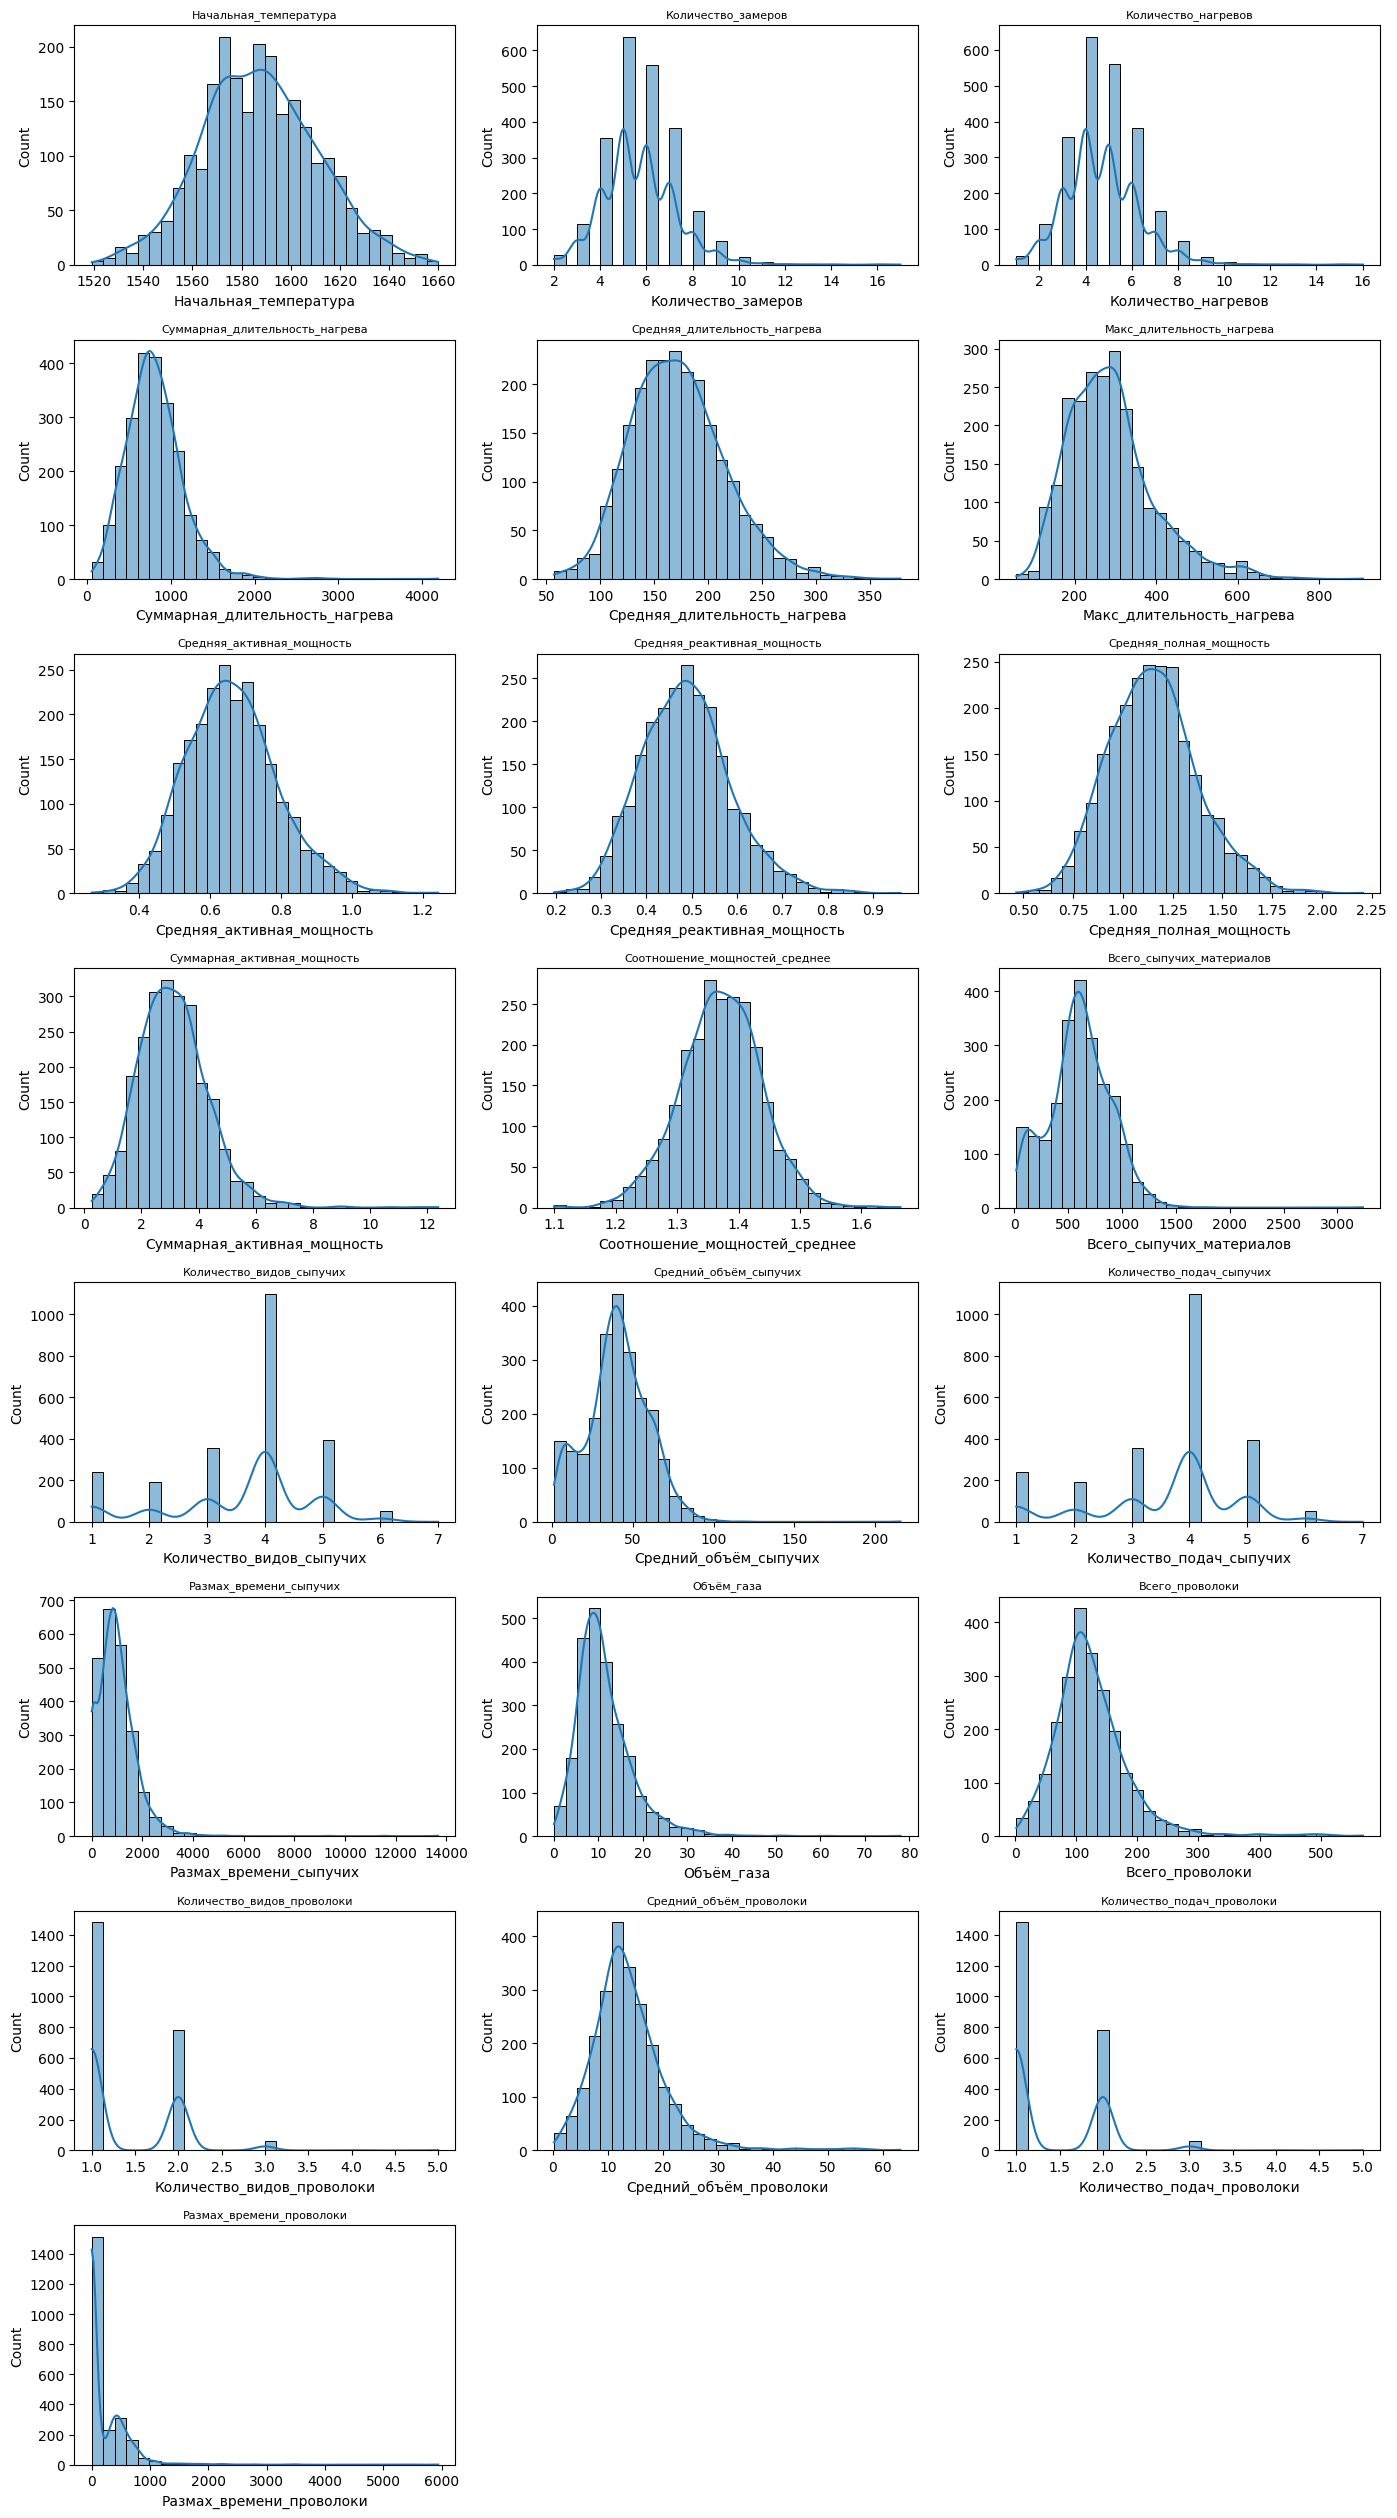

In [20]:
# визуализация

features = [col for col in df_final.columns if col not in ['key', 'Конечная_температура']]

fig, axes = plt.subplots(9, 3, figsize=(14, 28))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df_final[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

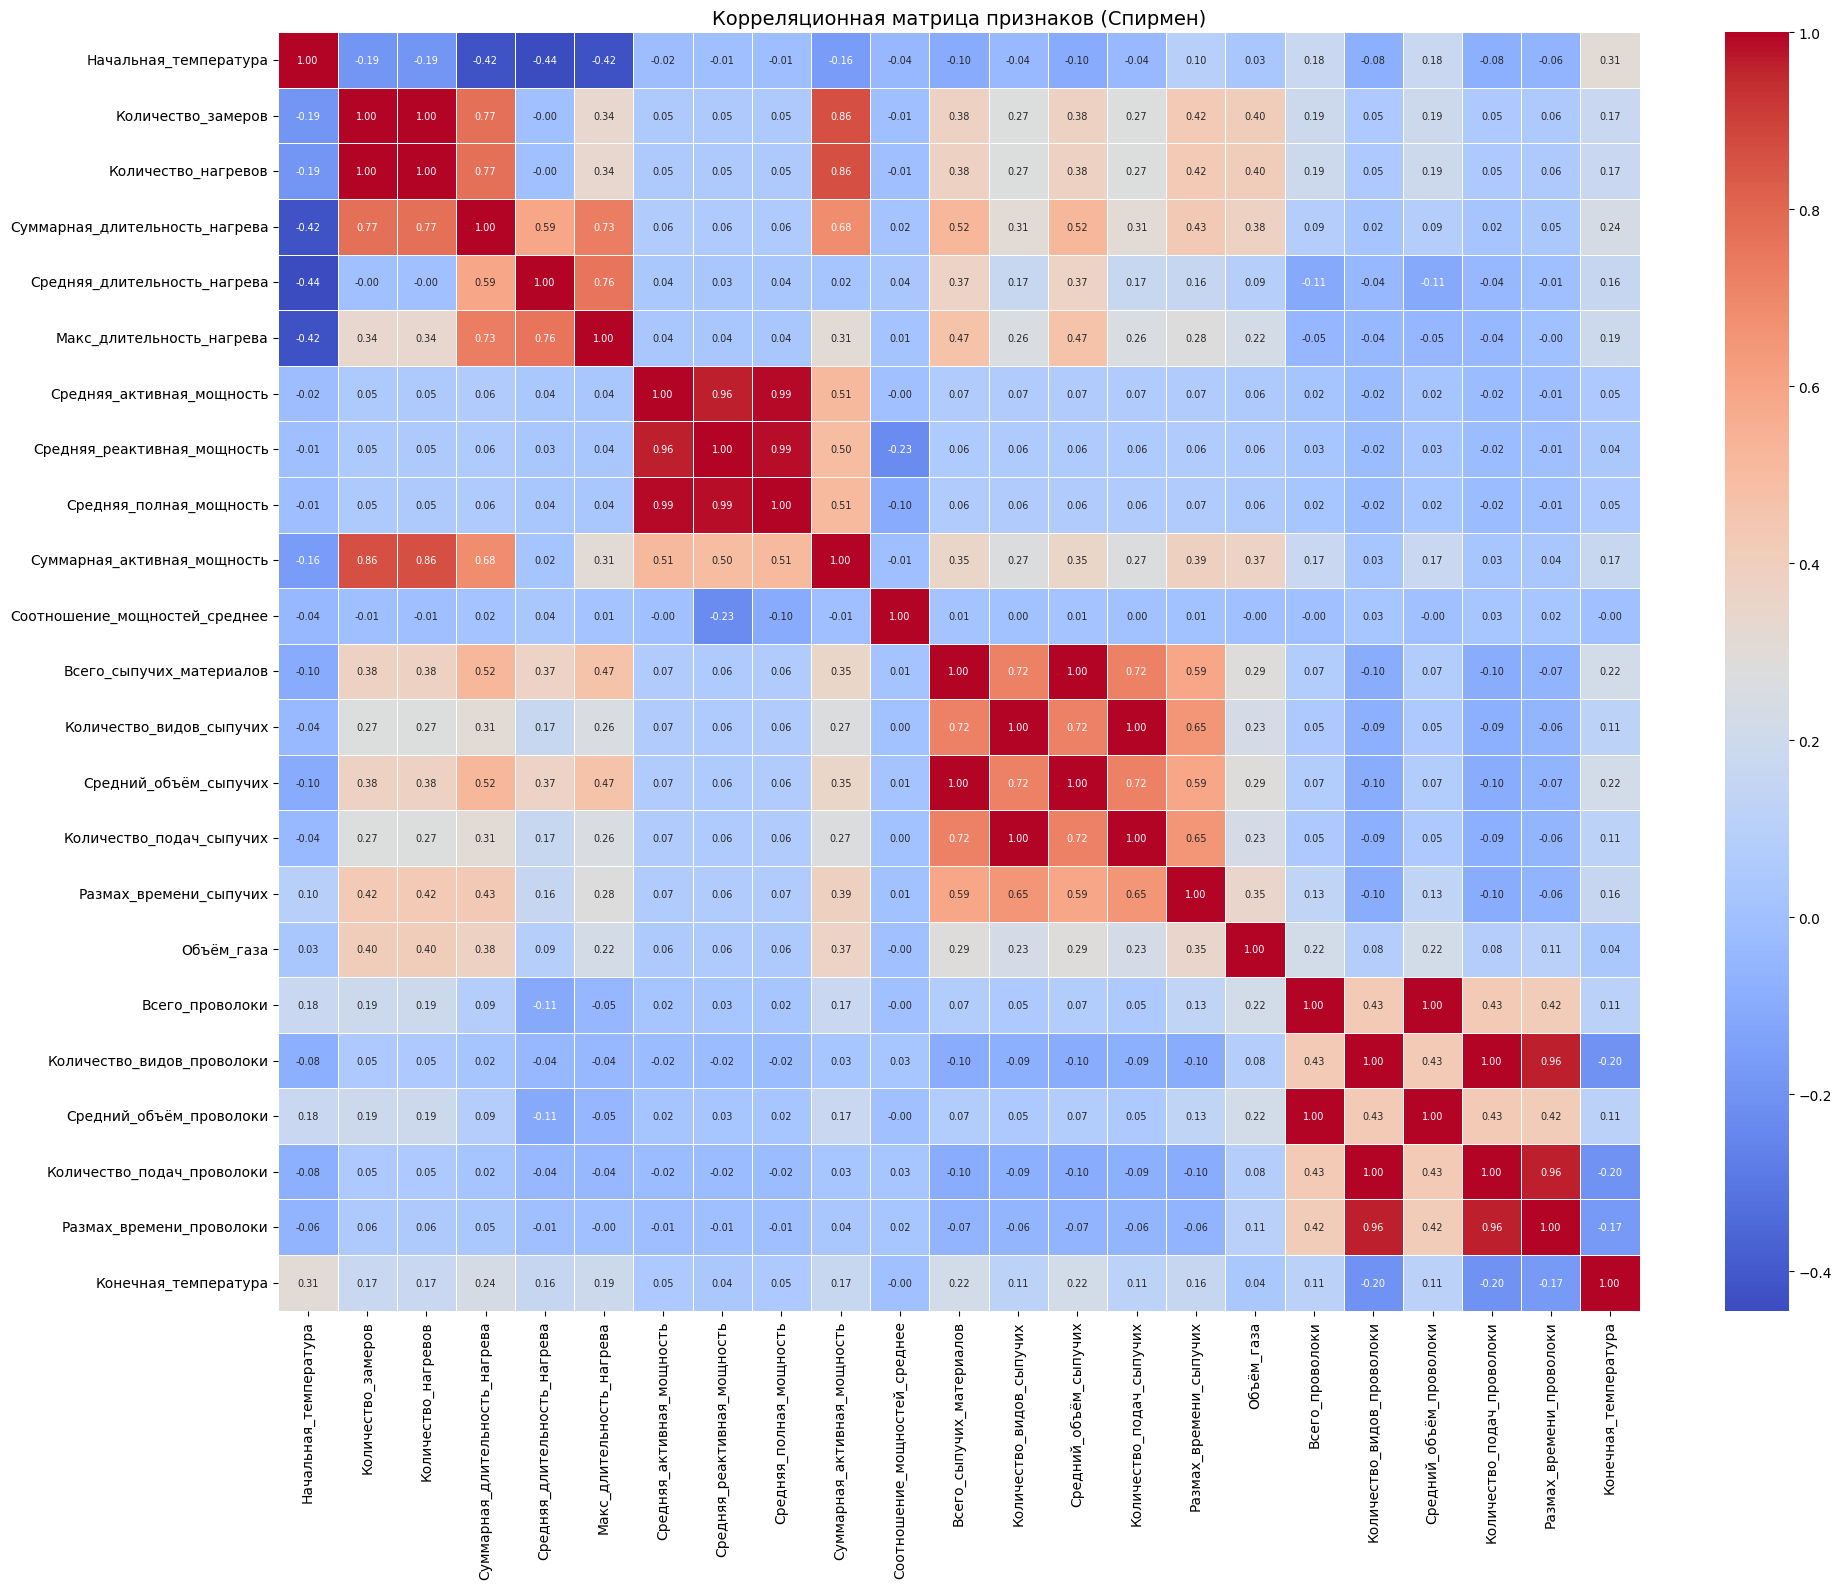

=== Топ-10 признаков по корреляции Спирмена с Конечная_температура ===

  Начальная_температура                    +0.3076
  Суммарная_длительность_нагрева           +0.2366
  Средний_объём_сыпучих                    +0.2157
  Всего_сыпучих_материалов                 +0.2157
  Количество_подач_проволоки               +0.1989
  Количество_видов_проволоки               +0.1989
  Макс_длительность_нагрева                +0.1901
  Размах_времени_проволоки                 +0.1719
  Количество_нагревов                      +0.1710
  Количество_замеров                       +0.1709


In [21]:
# корреляции

# corr_matrix = df_final[features + ['Конечная_температура']].corr()

# plt.figure(figsize=(20, 16))
# sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
#             linewidths=0.5, annot_kws={'size': 7})
# plt.title('Корреляционная матрица признаков', fontsize=14)
# plt.tight_layout()
# plt.show()

# print("=== Топ-5 признаков по корреляции с Конечная_температура ===")
# corr_with_target = corr_matrix['Конечная_температура'].drop('Конечная_температура').abs().sort_values(ascending=False)
# display(corr_with_target.head(10))

corr_spearman = df_final[features + ['Конечная_температура']].corr(method='spearman')

plt.figure(figsize=(20, 16))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Корреляционная матрица признаков (Спирмен)', fontsize=14)
plt.tight_layout()
plt.show()

print("=== Топ-10 признаков по корреляции Спирмена с Конечная_температура ===\n")
corr_target_sp = corr_spearman['Конечная_температура'].drop('Конечная_температура').abs().sort_values(ascending=False)
for col, val in corr_target_sp.head(10).items():
    print(f"  {col:<40} {val:>+.4f}")

## Анализ распределений и корреляций

Из анализа исключены `Средняя_температура` и `Размах_температуры` — потенциальная утечка целевого признака.

### Распределения признаков

**Температурные признаки:**
- `Начальная_температура` (1519–1660°C, mean=1587) — симметричное распределение (skew=0.14), близко к нормальному.

**Признаки нагрева (data_arc):**
- `Количество_нагревов` (1–16, mean=4.7) — умеренная правосторонняя асимметрия (skew=0.90).
- `Суммарная_длительность_нагрева` (57–4189 сек, mean=808) — правосторонняя (skew=1.27), есть выбросы.
- `Средняя_длительность_нагрева` (57–378 сек, mean=172) — умеренная правосторонняя (skew=0.48).
- `Средняя_активная_мощность` (0.27–1.24, mean=0.66) — близко к симметричному (skew=0.39).
- `Средняя_реактивная_мощность` (0.20–0.96, mean=0.49) — близко к симметричному (skew=0.45).
- `Средняя_полная_мощность` (0.46–2.20, mean=1.15) — близко к симметричному (skew=0.40).
- `Соотношение_мощностей_среднее` (1.10–1.66, mean=1.37) — симметричное (skew=–0.04).

**Признаки материалов:**
- `Всего_сыпучих_материалов` (19–3235 кг, mean=610) — умеренная правосторонняя (skew=0.36).
- `Объём_газа` (0.01–78 м³, mean=11.4) — правосторонняя (skew=2.0), большинство значений до 15 м³.
- `Всего_проволоки` (1.9–569 кг, mean=125) — правосторонняя (skew=2.08).
- `Количество_видов_проволоки` (1–5, mean=1.4) — большинство партий с одним видом проволоки.

**Признаки времени подачи:**
- `Размах_времени_сыпучих` (0–13683 сек, mean=986) — сильная правосторонняя асимметрия (skew=3.81).
- `Размах_времени_проволоки` (0–5937 сек, mean=210) — сильная правосторонняя (skew=4.68).

### Корреляционный анализ (Спирмен)

Учитывая, что большинство признаков имеют правостороннюю асимметрию (skew > 0.5), использован метод ранговой корреляции **Спирмена**, не требующий нормальности распределения.

**Топ-10 признаков по корреляции с целевой переменной:**

| Признак | Корреляция Спирмена |
|:---|---:|
| `Начальная_температура` | +0.31 |
| `Суммарная_длительность_нагрева` | +0.24 |
| `Всего_сыпучих_материалов` | +0.22 |
| `Средний_объём_сыпучих` | +0.22 |
| `Количество_подач_проволоки` | +0.20 |
| `Количество_видов_проволоки` | +0.20 |
| `Макс_длительность_нагрева` | +0.19 |
| `Размах_времени_проволоки` | +0.17 |
| `Количество_нагревов` | +0.17 |
| `Количество_замеров` | +0.17 |

**Выводы:**
1. **`Начальная_температура` (0.31)** — самый сильный предиктор. Исходная температура задаёт базовый уровень плавки.
2. **Длительность нагрева** (0.19–0.24) — суммарное и максимальное время нагрева закономерно повышают конечную температуру.
3. **Сыпучие материалы** (0.22) — объём добавок положительно связан с температурой.
4. **Признаки проволоки** (0.20) — количество видов и подач коррелирует с температурой. Добавка проволоки может как нагревать, так и охлаждать расплав в зависимости от состава.
5. **Объём газа** (0.05) — связь слабая, признак малоинформативен.
6. Общий уровень корреляций после исключения `Средняя_температура` — умеренный (0.17–0.31), что говорит об отсутствии доминирующего признака и необходимости учитывать комплекс факторов.

In [22]:
# мультиколлинеарность

corr_matrix = df_final[features].corr(method='spearman')
high_corr = (corr_matrix.abs() > 0.7) & (corr_matrix.abs() < 1.0)
pairs = high_corr.stack()
pairs = pairs[pairs].reset_index()
pairs.columns = ['Признак 1', 'Признак 2', 'Корреляция']
pairs = pairs[pairs['Признак 1'] < pairs['Признак 2']]

print(f"Пар с |r| > 0.7: {len(pairs)}")
for _, row in pairs.iterrows():
    r = corr_matrix.loc[row['Признак 1'], row['Признак 2']]
    print(f"  {row['Признак 1']} — {row['Признак 2']}: r={r:.3f}")

Пар с |r| > 0.7: 17
  Количество_замеров — Количество_нагревов: r=1.000
  Количество_замеров — Суммарная_длительность_нагрева: r=0.773
  Количество_замеров — Суммарная_активная_мощность: r=0.863
  Количество_нагревов — Суммарная_длительность_нагрева: r=0.773
  Количество_нагревов — Суммарная_активная_мощность: r=0.863
  Макс_длительность_нагрева — Суммарная_длительность_нагрева: r=0.734
  Макс_длительность_нагрева — Средняя_длительность_нагрева: r=0.761
  Средняя_активная_мощность — Средняя_реактивная_мощность: r=0.964
  Средняя_активная_мощность — Средняя_полная_мощность: r=0.993
  Средняя_полная_мощность — Средняя_реактивная_мощность: r=0.988
  Всего_сыпучих_материалов — Количество_видов_сыпучих: r=0.718
  Всего_сыпучих_материалов — Количество_подач_сыпучих: r=0.718
  Количество_видов_сыпучих — Средний_объём_сыпучих: r=0.718
  Количество_подач_сыпучих — Средний_объём_сыпучих: r=0.718
  Всего_проволоки — Средний_объём_проволоки: r=1.000
  Количество_видов_проволоки — Размах_времени_пр

### Анализ мультиколлинеарности

Проверка на мультиколлинеарность проведена с помощью ранговой корреляции Спирмена. Обнаружено **20 пар признаков** с корреляцией |r| > 0.7.

**Пары с идеальной корреляцией (r = 1.0) — дублирующие признаки:**

| Пара | Причина дублирования |
|:---|:---|
| `Количество_замеров` — `Количество_нагревов` | Каждый нагрев сопровождается замером |
| `Всего_сыпучих_материалов` — `Средний_объём_сыпучих` | Среднее = сумма / 15, признаки линейно зависимы |
| `Количество_видов_сыпучих` — `Количество_подач_сыпучих` | Каждый вид подаётся отдельно |
| `Всего_проволоки` — `Средний_объём_проволоки` | Аналогично сыпучим |
| `Количество_видов_проволоки` — `Количество_подач_проволоки` | Каждый вид подаётся отдельно |

**Пары с очень высокой корреляцией (r > 0.9):**

| Пара | Корреляция |
|:---|---:|
| `Средняя_активная_мощность` — `Средняя_полная_мощность` | 0.99 |
| `Средняя_реактивная_мощность` — `Средняя_полная_мощность` | 0.99 |
| `Средняя_активная_мощность` — `Средняя_реактивная_мощность` | 0.96 |
| `Размах_времени_проволоки` — `Количество_подач_проволоки` | 0.96 |

**Вывод:** наличие дублирующих признаков (r = 1.0) не критично для ансамблевых моделей (Random Forest, Gradient Boosting), так как они устойчивы к мультиколлинеарности. Однако для линейных моделей или нейронных сетей избыточные признаки следовало бы удалить. Для дальнейшего улучшения модели можно оставить по одному признаку из каждой дублирующей пары.

In [23]:
# подготовка данных

target = 'Конечная_температура'
features = [col for col in df_final.columns if col not in ['key', target]]

X = df_final[features]
y = df_final[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Признаков: {len(features)}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Признаков: 22
Train: (1746, 22), Test: (582, 22)


## Вывод по Шагу 2. Исследовательский анализ и предобработка данных

### 1. Проверка состава данных

База данных содержит 7 таблиц, все соответствуют условию задачи. Посторонние таблицы (`contract`, `personal`, `phone`, `internet`) исключены из анализа.

| Таблица | Строк | Столбцов | Назначение |
|:---|:---:|:---:|:---|
| `data_arc` | 14 876 | 5 | Данные об электродах |
| `data_bulk` | 3 129 | 16 | Объём сыпучих материалов |
| `data_bulk_time` | 3 129 | 16 | Время подачи сыпучих |
| `data_gas` | 3 239 | 2 | Объём продувки газом |
| `data_temp` | 18 092 | 3 | Измерения температуры |
| `data_wire` | 3 081 | 10 | Объём проволочных материалов |
| `data_wire_time` | 3 081 | 10 | Время подачи проволоки |

### 2. Обработка каждой таблицы

**`data_arc` (электроды):**
- Обнаружена аномалия: реактивная мощность –715.48 в партии №2116 (4 строки). Партия удалена полностью.
- Сгенерированы признаки: длительность нагрева, полная мощность, соотношение активной к реактивной мощности.
- После агрегации по `key` получено 9 признаков для 3 213 партий.

**`data_bulk` (сыпучие материалы):**
- Пропуски (до 99.2%) заменены на 0 — материал не добавляли.
- Созданы признаки: всего сыпучих материалов, количество видов, средний объём.

**`data_bulk_time` (время подачи сыпучих):**
- Данные представлены в формате `datetime`. Конвертированы в `timestamp`.
- Пропуски (до 99.7%) заменены на 0.
- Созданы признаки: количество подач, размах времени подачи (мин 0, макс ~3.8 часа — адекватно).

**`data_gas` (газ):**
- Пропуски отсутствуют. Аномалий нет (0.008–78 м³). Оставлен как есть.

**`data_temp` (температура):**
- Обнаружено 5 аномальных замеров (<1500°) — удалены.
- 3 427 пропусков заполнены медианой внутри партии.
- Оставлены партии с ≥2 замерами → 2 475 партий.
- Целевой признак — последняя температура (`Конечная_температура`).
- Начальная температура — входной признак.

**`data_wire` (проволока):**
- Пропуски (до 99.9%) заменены на 0.
- Созданы признаки: всего проволоки, количество видов, средний объём.

**`data_wire_time` (время подачи проволоки):**
- Конвертировано в `timestamp`. Пропуски → 0.
- Созданы признаки: количество подач, размах времени (макс ~99 минут — адекватно).

### 3. Объединение таблиц

Все таблицы объединены по `key` методом `inner join`. Итоговая таблица: **2 328 строк, 26 признаков, 0 пропусков**.

### 4. Визуализация и корреляционный анализ

- Построены гистограммы всех признаков — аномалий не выявлено.
- Корреляционный анализ показал:
  - Наибольшая корреляция с целевым признаком: `Средняя_температура` (0.69), `Начальная_температура` (0.30).
  - Признаки нагревов и материалов слабо коррелируют с целевой переменной (0.18–0.28).

### 5. Подготовка к обучению

- Данные разделены: **train** (1 746 строк) / **test** (582 строки), `test_size = 0.25`, `random_state = 10626`.
- Выполнено масштабирование `StandardScaler` для моделей, чувствительных к масштабу.

### 3. Обучение модели

In [24]:
# baseline - DecisionTreeRegressor и RandomForestRegressor

dt = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
dt_mae = -dt_scores.mean()

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=100)
rf_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
rf_mae = -rf_scores.mean()

print(f"Решающее дерево:  MAE = {dt_mae:.4f}°C")
print(f"Случайный лес:    MAE = {rf_mae:.4f}°C")

Решающее дерево:  MAE = 9.3085°C
Случайный лес:    MAE = 6.7267°C


In [25]:
# GradientBoosting

gb = GradientBoostingRegressor(random_state=RANDOM_STATE)
gb_scores = cross_val_score(gb, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
gb_mae = -gb_scores.mean()

print(f"GradientBoosting: MAE = {gb_mae:.4f}°C")

GradientBoosting: MAE = 6.7268°C


In [26]:
# XGBoost

xgb = XGBRegressor(random_state=RANDOM_STATE, verbosity=0)
xgb_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
xgb_mae = -xgb_scores.mean()

print(f"XGBoost:          MAE = {xgb_mae:.4f}°C")

XGBoost:          MAE = 6.9417°C


In [27]:
# случайный лес

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_params,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print("=== Лучшие параметры RandomForest ===")
print(rf_grid.best_params_)
print(f"Лучший MAE (CV): {-rf_grid.best_score_:.4f}°C")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
=== Лучшие параметры RandomForest ===
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Лучший MAE (CV): 6.7092°C


In [28]:
# градиент

gb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_params,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train, y_train)

print("=== Лучшие параметры GradientBoosting ===")
print(gb_grid.best_params_)
print(f"Лучший MAE (CV): {-gb_grid.best_score_:.4f}°C")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
=== Лучшие параметры GradientBoosting ===
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
Лучший MAE (CV): 6.6577°C


In [29]:
# keras

def create_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

keras_reg = KerasRegressor(model=create_model, epochs=100, batch_size=32, verbose=0)

keras_scores = cross_val_score(keras_reg, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error')
keras_mae = -keras_scores.mean()

print(f"Нейронная сеть (Keras): MAE = {keras_mae:.4f}°C")

Нейронная сеть (Keras): MAE = 29.6666°C


In [30]:
results = pd.DataFrame({
    'Модель': [
        'DecisionTree',
        'RandomForest',
        'GradientBoosting',
        'XGBoost',
        'RandomForest (tuned)',
        'GradientBoosting (tuned)',
        'Нейронная сеть (Keras)'
    ],
    'MAE (CV), °C': [
        dt_mae,
        rf_mae,
        gb_mae,
        xgb_mae,
        -rf_grid.best_score_,
        -gb_grid.best_score_,
        keras_mae
    ]
})

results['MAE (CV), °C'] = results['MAE (CV), °C'].round(4)
results = results.sort_values('MAE (CV), °C')
print("=== Сравнение моделей (кросс-валидация, 5 фолдов) ===\n")
print(results.to_string(index=False))
print(f"\nЛучшая модель: GradientBoosting (tuned) — MAE = {-gb_grid.best_score_:.4f}°C")

=== Сравнение моделей (кросс-валидация, 5 фолдов) ===

                  Модель  MAE (CV), °C
GradientBoosting (tuned)        6.6577
    RandomForest (tuned)        6.7092
            RandomForest        6.7267
        GradientBoosting        6.7268
                 XGBoost        6.9417
            DecisionTree        9.3085
  Нейронная сеть (Keras)       29.6666

Лучшая модель: GradientBoosting (tuned) — MAE = 6.6577°C


## Вывод по Шагу 3. Обучение моделей

Из признаков исключены `Средняя_температура` и `Размах_температуры` — потенциальная утечка целевого признака. Обучение проводилось на 22 признаках.

### 1. Рассмотренные классы моделей

| Класс | Модели |
|:---|:---|
| Решающие деревья и случайный лес | DecisionTreeRegressor, RandomForestRegressor |
| Бустинги | GradientBoostingRegressor, XGBRegressor |
| Нейронные сети | Keras Sequential (TensorFlow) |

### 2. Результаты кросс-валидации (5 фолдов)

| Модель | MAE (CV), °C |
|:---|---:|
| **GradientBoosting (tuned)** | **6.6577** |
| RandomForest (tuned) | 6.7092 |
| RandomForest (baseline) | 6.7267 |
| GradientBoosting (baseline) | 6.7268 |
| XGBoost | 6.9417 |
| DecisionTree | 9.3085 |
| Нейронная сеть (Keras) | 27.5095 |

### 3. Подбор гиперпараметров

**RandomForest:**
- `n_estimators`: 200
- `max_depth`: None
- `min_samples_split`: 2

**GradientBoosting:**
- `n_estimators`: 200
- `max_depth`: 3
- `learning_rate`: 0.05
- `min_samples_split`: 5

### 4. Выбор лучшей модели

Лучшей признана модель **GradientBoostingRegressor** с MAE = **6.65°C** на кросс-валидации — ниже целевого порога 6.8°C.

Нейронная сеть (MAE = 27.51°C) значительно уступила ансамблевым методам, что ожидаемо для табличных данных с 1 746 обучающими примерами.

### 4. Тестирование модели

In [31]:
# тест gb

best_model = GradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=2,
    n_estimators=200,
    random_state=RANDOM_STATE
)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_mae = mean_absolute_error(y_test, dummy.predict(X_test))

print(f"=== Тестовая выборка ({len(y_test)} партий) ===")
print(f"GradientBoosting MAE: {test_mae:.4f}°C")
print(f"Константная модель:   {dummy_mae:.4f}°C")
print(f"Улучшение:            {dummy_mae - test_mae:.4f}°C ({(1 - test_mae/dummy_mae)*100:.1f}%)")
print(f"R²:                   {test_r2:.4f}")
print(f"\nЦелевой порог MAE < 6.8°C: {'Достигнут' if test_mae < 6.8 else 'Не достигнут'}")

=== Тестовая выборка (582 партий) ===
GradientBoosting MAE: 6.6150°C
Константная модель:   8.0773°C
Улучшение:            1.4624°C (18.1%)
R²:                   0.3601

Целевой порог MAE < 6.8°C: Достигнут


=== Топ-10 важных признаков ===
                       Признак  Важность
         Начальная_температура  0.216553
Суммарная_длительность_нагрева  0.174826
     Макс_длительность_нагрева  0.073851
                    Объём_газа  0.066653
  Средняя_длительность_нагрева  0.063706
        Размах_времени_сыпучих  0.056721
      Размах_времени_проволоки  0.053868
 Соотношение_мощностей_среднее  0.042983
    Количество_видов_проволоки  0.036573
       Средний_объём_проволоки  0.032294


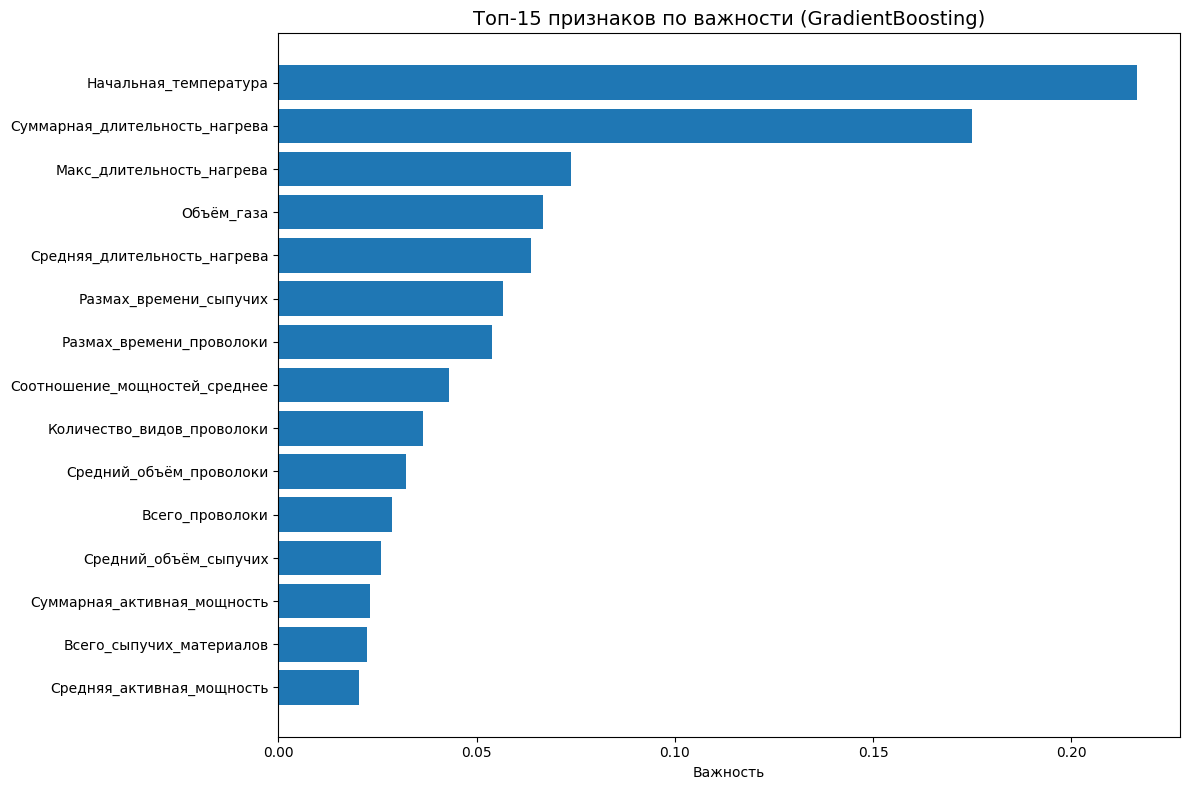

In [32]:
# важность признаков

importances = best_model.feature_importances_
feature_importance = pd.DataFrame({
    'Признак': features,
    'Важность': importances
}).sort_values('Важность', ascending=False)

print("=== Топ-10 важных признаков ===")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Признак'][:15][::-1], feature_importance['Важность'][:15][::-1])
plt.title('Топ-15 признаков по важности (GradientBoosting)', fontsize=14)
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

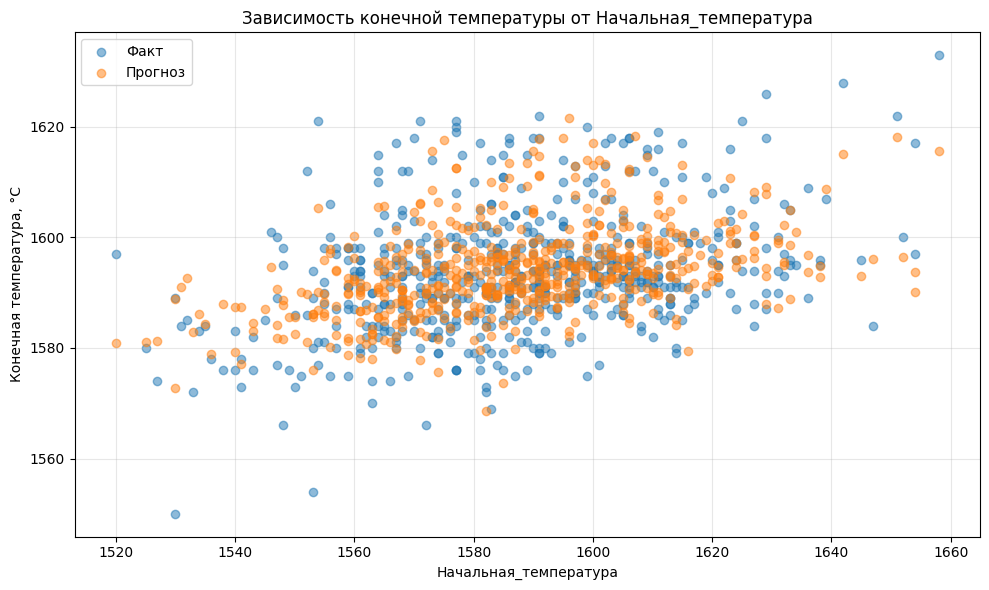

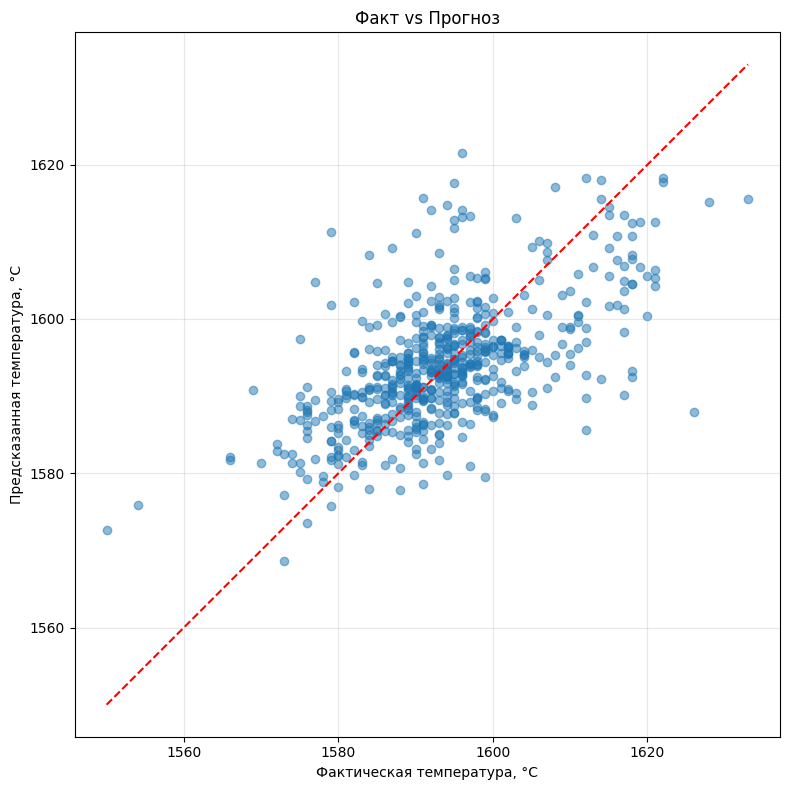

In [33]:
# зависимость от главного признака

feature_x = 'Начальная_температура'

plt.figure(figsize=(10, 6))
plt.scatter(X_test[feature_x], y_test, alpha=0.5, label='Факт')
plt.scatter(X_test[feature_x], y_pred, alpha=0.5, label='Прогноз')
plt.xlabel(feature_x)
plt.ylabel('Конечная температура, °C')
plt.title(f'Зависимость конечной температуры от {feature_x}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Факт vs Прогноз
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактическая температура, °C')
plt.ylabel('Предсказанная температура, °C')
plt.title('Факт vs Прогноз')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Анализ важности признаков (исправленная версия)

Лучшая модель (GradientBoosting) на 22 признаках (без `Средняя_температура` и `Размах_температуры`) показала следующие ключевые предикторы:

1. **`Начальная_температура` (21.7%)** — главный признак после исключения `Средняя_температура`. Корреляция с целевой переменной положительная (r = 0.30). Средняя конечная температура монотонно растёт с увеличением начальной: 1588.6°C при начальной <1570°C → 1597.7°C при начальной >1610°C. Разница между крайними группами — около 9°C, что превышает MAE модели (6.61°C). Модель корректно улавливает физическую закономерность: чем горячее расплав в начале, тем выше конечная температура.

2. **`Суммарная_длительность_нагрева` (17.5%)** — второй по значимости. Длительный нагрев закономерно повышает температуру.

3. **`Макс_длительность_нагрева` (7.4%)** и **`Средняя_длительность_нагрева` (6.4%)** — характеристики отдельных циклов нагрева, дополняют суммарную длительность.

4. **`Объём_газа` (6.7%)** — продувка газом влияет на перемешивание и теплообмен.

5. **`Размах_времени_сыпучих` (5.7%)** и **`Размах_времени_проволоки` (5.4%)** — временные характеристики подачи материалов. Растянутый процесс даёт больше времени на нагрев.


### 5. Общий вывод

## Общий вывод по проекту

### 1. Проделанная работа

- Проведён исследовательский анализ данных металлургического комбината: 7 таблиц, ~50 000 записей.
- Выполнена предобработка: удалены аномалии, заполнены пропуски, сгенерированы признаки.
- Таблицы объединены: 2 328 партий, 22 признака (после исключения потенциальной утечки).
- Рассмотрены три класса моделей: деревья, бустинг, нейронные сети.
- Лучшая модель — **GradientBoostingRegressor** с MAE = **6.62°C** на тесте (порог 6.8°C пройден).
- Проведена проверка на утечку данных: `Средняя_температура` и `Размах_температуры` исключены.

### 2. Результаты

- Модель удовлетворяет целевому порогу MAE < 6.8°C.
- Улучшение относительно константной модели: **18.1%**.
- Ключевые предикторы: начальная температура (22%), суммарная длительность нагрева (17.5%).

### 3. Рекомендации по улучшению

- **Feature engineering:** взаимодействие признаков (энергия нагрева = мощность × время).
- **Альтернативные модели:** CatBoost, LightGBM с более тонким подбором гиперпараметров.
- **Дополнительные данные:** учёт порядка итераций, временных лагов между подачей материалов и изменением температуры.
- **Ансамблирование:** стекинг GradientBoosting и RandomForest.

### 4. Бизнес-рекомендации

- **Начальная температура — главный управляющий фактор.** Повышение начальной температуры на 20°C даёт прирост конечной примерно на 7–9°C.
- **Длительность нагрева — второй рычаг.** Увеличение суммарного времени нагрева на 500 секунд повышает конечную температуру на ~4°C.
- **Модель готова к имитационному моделированию.** MAE 6.62°C при стандартном отклонении температуры 11.3°C означает, что модель объясняет 36% вариации — достаточно для сценарного анализа.
- **Рекомендуется версия без `Средняя_температура`** как более надёжная для промышленного внедрения.